***GROUP 12 MEMBERS***
* **JUMA CLINI BENSON      SCT213-C002-0120/2024**
* **MILANETTO DANIEL       SCT213-C002-0010/2024**
* **ABDULLAHI YUSSUF       SCT213-C002-0132/2024**
* **MIKE GITONGA           SCT213-C002-0011/2024**
* **AHMED IBRAHIM          SCT213-C002-0100/2024**

***MUTIVARIATE ANALYSIS AND PREDICTION OF CH₄(METHANE) AND N₂O(NITROUS OXIDE) EMISSIONS ACROSS COUNTRIES***
* How do CH₄ and N₂O emissions vary across countries and world regions, and how effectively can emission reduction status—defined as a binary indicator of whether a country has reduced emissions since 1990—be predicted using per-capita emissions and geographic classification?

# Milestone 1, 2, 3, 4

### Importing tidyverse

In [126]:
#importing tidyverse library to enable data acquisition ,data manipulation and visualization through its packages
library(tidyverse)

## Data Acquisition
* Using Air pollution gas from Kaggle as written by UNSD

In [35]:
#Data Acquisition
df <- read.csv("CH4_N2O_Emissions.csv", 
               stringsAsFactors = FALSE,
               na.strings = c("...", "", "NA")) %>%
  as_tibble()

## Data Schema and Variable definitions

In [36]:
head(df)

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,X..change.since.1990,N2O.emissions,N2O.emissions.per.capita,X..change.since.1990.1,X
<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>
Afghanistan,2005,10.16,0.42,NA,5.94,0.24,NA,NA
Albania,1994,2.14,0.68,NA,0.29,0.09,NA,NA
Algeria,2000,32.92,1.06,NA,6.50,0.21,NA,NA
Angola,2005,19.93,1.11,NA,13.87,0.77,NA,NA
Antigua and Barbuda,2000,0.14,1.83,43.74,0.08,1.08,5197.47,NA
Argentina,2000,84.85,2.29,10.50,67.50,1.82,30.26,NA


In [37]:
tail(df)

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,X..change.since.1990,N2O.emissions,N2O.emissions.per.capita,X..change.since.1990.1,X
<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA


In [38]:
#Data Schema and variable definitions
dim(df)

[1] 204   9

In [39]:
#Columns
names(df)

[1] "Country"                  "latest.year.available"   
[3] "CH4.emissions"            "CH4.emissions.per.capita"
[5] "X..change.since.1990"     "N2O.emissions"           
[7] "N2O.emissions.per.capita" "X..change.since.1990.1"  
[9] "X"

In [40]:
#data types and internal structure
glimpse(df)

Rows: 204
Columns: 9
$ Country                  <chr> "Afghanistan", "Albania", "Algeria", "Angola"…
$ latest.year.available    <int> 2005, 1994, 2000, 2005, 2000, 2000, 2010, 201…
$ CH4.emissions            <dbl> 10.16, 2.14, 32.92, 19.93, 0.14, 84.85, 2.26,…
$ CH4.emissions.per.capita <dbl> 0.42, 0.68, 1.06, 1.11, 1.83, 2.29, 0.76, 4.8…
$ X..change.since.1990     <dbl> NA, NA, NA, NA, 43.74, 10.50, -28.66, -3.02, …
$ N2O.emissions            <chr> "5.94", "0.29", "6.50", "13.87", "0.08", "67.…
$ N2O.emissions.per.capita <chr> "0.24", "0.09", "0.21", "0.77", "1.08", "1.82…
$ X..change.since.1990.1   <chr> NA, NA, NA, NA, "5197.47", "30.26", "185.46",…
$ X                        <lgl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, N…


In [41]:
#Renaming columns for clarity
df <- df %>%
  rename(
    CH4.change.since.1990 = X..change.since.1990,
    N2O.change.since.1990 = X..change.since.1990.1
  )

## Data Cleaning and Transformations

### Type Casting

In [42]:
#Data Transformation
#Type Casting
#Converting data type of N20.emissions from character to double for numerical operations
df$N2O.emissions <- suppressWarnings(as.double(df$N2O.emissions))

In [43]:
#Converting data type of N20.emissions.per.capita from character to double for numerical operations
df$N2O.emissions.per.capita <- suppressWarnings(as.double(df$N2O.emissions.per.capita))

In [44]:
#Converting data type of N20.emissions.per.capita from character to double for numerical operations
df$N2O.change.since.1990 <- suppressWarnings(as.double(df$N2O.change.since.1990))

### Duplicates

In [45]:
#position of the first duplicated value
anyDuplicated(df)

[1] 186

In [46]:
#total no. of duplicated rows
sum(duplicated(df))

[1] 19

In [47]:
df[duplicated(df), ]

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,CH4.change.since.1990,N2O.emissions,N2O.emissions.per.capita,N2O.change.since.1990,X
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA


In [48]:
#remove duplicated rows
df <- unique(df)

In [49]:
tail(df)

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,CH4.change.since.1990,N2O.emissions,N2O.emissions.per.capita,N2O.change.since.1990,X
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
Venezuela (Bolivarian Republic of),1999,61.92,2.58,NA,16.14,0.67,NA,NA
Viet Nam,2010,87.32,0.99,NA,32.70,0.37,NA,NA
Yemen,2000,4.42,0.25,NA,3.77,0.21,NA,NA
Zambia,2000,6.57,0.62,NA,5.33,0.50,NA,NA
Zimbabwe,2000,7.48,0.60,NA,36.20,2.90,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA


In [50]:
#To remove last row
df <- df[-nrow(df), ]

In [51]:
tail(df)

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,CH4.change.since.1990,N2O.emissions,N2O.emissions.per.capita,N2O.change.since.1990,X
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
Vanuatu,1994,0.24,1.43,NA,0.01,0.05,NA,NA
Venezuela (Bolivarian Republic of),1999,61.92,2.58,NA,16.14,0.67,NA,NA
Viet Nam,2010,87.32,0.99,NA,32.70,0.37,NA,NA
Yemen,2000,4.42,0.25,NA,3.77,0.21,NA,NA
Zambia,2000,6.57,0.62,NA,5.33,0.50,NA,NA
Zimbabwe,2000,7.48,0.60,NA,36.20,2.90,NA,NA


### Missing values

#### Assessing the data for Missing values

In [62]:
#Data Quality Assessment to check missing values
colSums(is.na(df))

Country    latest.year.available            CH4.emissions 
                       0                        0                        0 
CH4.emissions.per.capita    CH4.change.since.1990            N2O.emissions 
                       0                       98                        0 
N2O.emissions.per.capita    N2O.change.since.1990 
                       0                       99

In [63]:
#percentage missing values
round(colMeans(is.na(df)) * 100, 2)

Country    latest.year.available            CH4.emissions 
                    0.00                     0.00                     0.00 
CH4.emissions.per.capita    CH4.change.since.1990            N2O.emissions 
                    0.00                    53.26                     0.00 
N2O.emissions.per.capita    N2O.change.since.1990 
                    0.00                    53.80

#### Dropping a cmpletely null column

In [64]:
#Remove column "X" since it is fully null
df <- df[, colMeans(is.na(df)) < 1]

In [65]:
head(df)

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,CH4.change.since.1990,N2O.emissions,N2O.emissions.per.capita,N2O.change.since.1990
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Afghanistan,2005,10.16,0.42,NA,5.94,0.24,NA
Albania,1994,2.14,0.68,NA,0.29,0.09,NA
Algeria,2000,32.92,1.06,NA,6.50,0.21,NA
Angola,2005,19.93,1.11,NA,13.87,0.77,NA
Antigua and Barbuda,2000,0.14,1.83,43.74,0.08,1.08,5197.47
Argentina,2000,84.85,2.29,10.50,67.50,1.82,30.26


#### Replacing few missing values columns with mean

In [66]:
mn.CH4.capita <- mean(df$CH4.emissions.per.capita, na.rm = TRUE)

In [67]:
df$CH4.emissions.per.capita[is.na(df$CH4.emissions.per.capita)] <- mn.CH4.capita

In [68]:
mn.N2O <- mean(df$N2O.emissions, na.rm = TRUE)

In [69]:
df$N2O.emissions[is.na(df$N2O.emissions)] <- mn.N2O

In [70]:
mn.N2O.capita <- mean(df$N2O.emissions.per.capita, na.rm = TRUE)

In [71]:
df$N2O.emissions.per.capita[is.na(df$N2O.emissions.per.capita)] <- mn.N2O.capita

#### Looking out for distribution, skewness, outliers to justify use for median

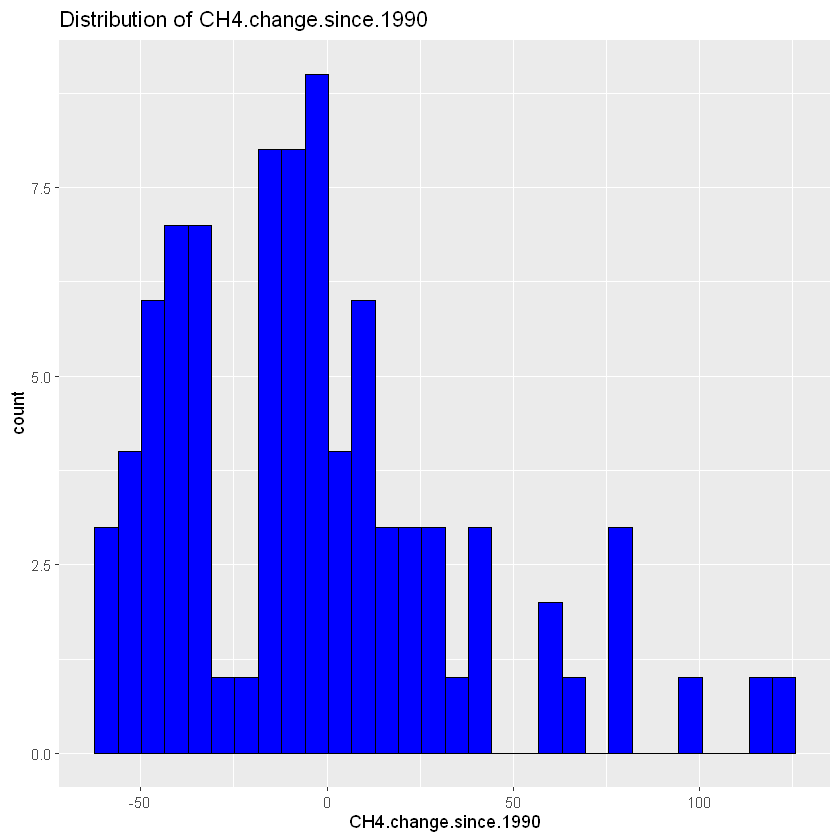

In [72]:
ggplot(df, aes(x = CH4.change.since.1990)) +
  geom_histogram(bins = 30, fill = "blue", color = "black", na.rm=TRUE) +
  ggtitle("Distribution of CH4.change.since.1990")

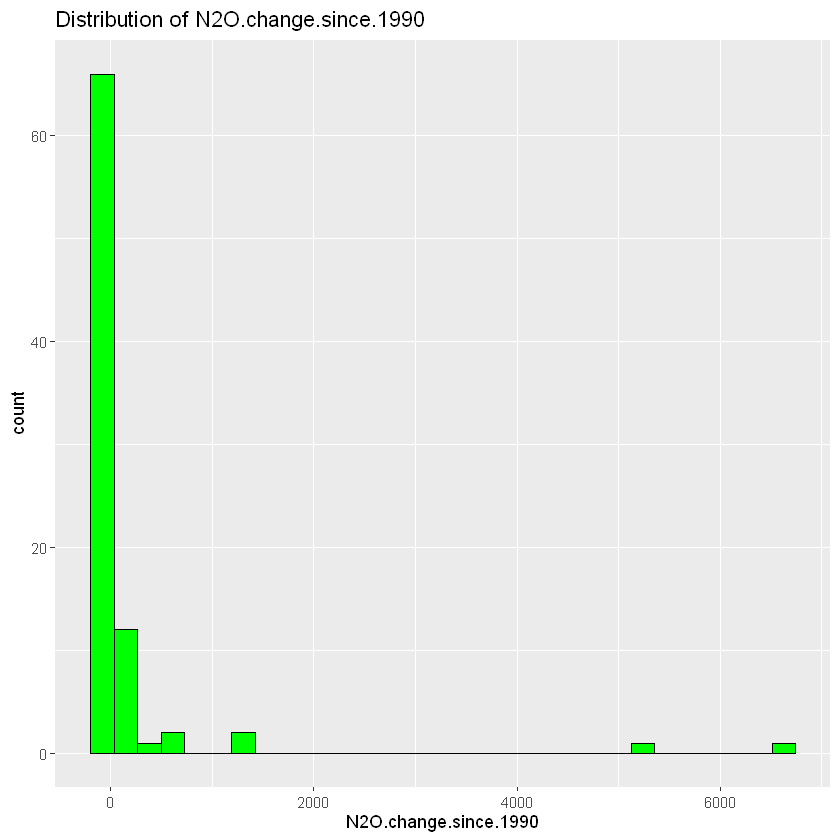

In [73]:
ggplot(df, aes(x = N2O.change.since.1990)) +
  geom_histogram(bins = 30, fill = "green", color = "black", na.rm=TRUE) +
  ggtitle("Distribution of N2O.change.since.1990")

In [127]:
library(e1071)

In [74]:
#type2 skewness = sample statistics
skew_chg = skewness(df$CH4.change.since.1990, na.rm = TRUE, type = 2)
skew_chg

[1] 1.020843

In [75]:
skew_chg.1 = skewness(df$N2O.change.since.1990, na.rm = TRUE, type = 2)
skew_chg.1

[1] 6.011556

In [76]:
#Due to outliers, median is suitable
mdn.CH4_Change <- median(df$CH4.change.since.1990, na.rm = TRUE)
df$CH4.change.since.1990[is.na(df$CH4.change.since.1990)] <- mdn.CH4_Change

In [77]:
#Due to outliers, median is suitable
mdn.N2O_Change <- median(df$N2O.change.since.1990, na.rm = TRUE)
df$N2O.change.since.1990[is.na(df$N2O.change.since.1990)] <- mdn.N2O_Change

In [78]:
#Transformation due to extreme skewness
df$N2O.change.since.1990 <- sign(df$N2O.change.since.1990) * (abs(df$N2O.change.since.1990)^(1/3))

In [79]:
#correct
skewness(df$N2O.change.since.1990, na.rm = TRUE,type=2)

[1] 3.162058

#### Data validation for missing values

In [80]:
#Validating the data
colSums(is.na(df))

Country    latest.year.available            CH4.emissions 
                       0                        0                        0 
CH4.emissions.per.capita    CH4.change.since.1990            N2O.emissions 
                       0                        0                        0 
N2O.emissions.per.capita    N2O.change.since.1990 
                       0                        0

In [81]:
head(df)

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,CH4.change.since.1990,N2O.emissions,N2O.emissions.per.capita,N2O.change.since.1990
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Afghanistan,2005,10.16,0.42,-7.035,5.94,0.24,-2.294505
Albania,1994,2.14,0.68,-7.035,0.29,0.09,-2.294505
Algeria,2000,32.92,1.06,-7.035,6.50,0.21,-2.294505
Angola,2005,19.93,1.11,-7.035,13.87,0.77,-2.294505
Antigua and Barbuda,2000,0.14,1.83,43.740,0.08,1.08,17.321972
Argentina,2000,84.85,2.29,10.500,67.50,1.82,3.116183


In [82]:
glimpse(df)

Rows: 184
Columns: 8
$ Country                  <chr> "Afghanistan", "Albania", "Algeria", "Angola"…
$ latest.year.available    <int> 2005, 1994, 2000, 2005, 2000, 2000, 2010, 201…
$ CH4.emissions            <dbl> 10.16, 2.14, 32.92, 19.93, 0.14, 84.85, 2.26,…
$ CH4.emissions.per.capita <dbl> 0.42, 0.68, 1.06, 1.11, 1.83, 2.29, 0.76, 4.8…
$ CH4.change.since.1990    <dbl> -7.035, -7.035, -7.035, -7.035, 43.740, 10.50…
$ N2O.emissions            <dbl> 5.94, 0.29, 6.50, 13.87, 0.08, 67.50, 0.48, 2…
$ N2O.emissions.per.capita <dbl> 0.24, 0.09, 0.21, 0.77, 1.08, 1.82, 0.16, 1.1…
$ N2O.change.since.1990    <dbl> -2.294505, -2.294505, -2.294505, -2.294505, 1…


## Basic descriptive statistics

In [83]:
#Basic descriptive statistics
summary(df)

   Country          latest.year.available CH4.emissions    
 Length:184         Min.   :1990          Min.   :  0.000  
 Class :character   1st Qu.:2000          1st Qu.:  1.290  
 Mode  :character   Median :2000          Median :  5.075  
                    Mean   :2003          Mean   : 30.878  
                    3rd Qu.:2010          3rd Qu.: 20.430  
                    Max.   :2012          Max.   :932.860  
 CH4.emissions.per.capita CH4.change.since.1990 N2O.emissions   
 Min.   :  0.0200         Min.   :-59.240       Min.   :  0.00  
 1st Qu.:  0.5475         1st Qu.: -7.035       1st Qu.:  0.45  
 Median :  0.8000         Median : -7.035       Median :  3.19  
 Mean   :  3.0856         Mean   : -5.091       Mean   : 17.04  
 3rd Qu.:  1.2950         3rd Qu.: -7.035       3rd Qu.: 11.93  
 Max.   :309.1000         Max.   :122.720       Max.   :395.79  
 N2O.emissions.per.capita N2O.change.since.1990
 Min.   :  0.000          Min.   :-4.264       
 1st Qu.:  0.180          1st

## Tabular summaries

In [84]:
#tabular visualization for Methane emissions
df_stats<- df%>%
summarize(
    Mean = mean(CH4.emissions),
    Variance = var(CH4.emissions),
    Standard.Deviation = sd(CH4.emissions),
    No.Of.Observations = n()
  )
df_stats

Mean,Variance,Standard.Deviation,No.Of.Observations
<dbl>,<dbl>,<dbl>,<int>
30.87837,9454.304,97.23325,184


In [85]:
#Average Methane Emissions per Country
regional_summary<-df%>%group_by(Country) %>%
  summarize(
    Avg_Emission = mean(CH4.emissions)
  ) %>%
  arrange(desc(Avg_Emission))

print(regional_summary)

# A tibble: 184 × 2
   Country                  Avg_Emission
   <chr>                           <dbl>
 1 China                           933. 
 2 United States of America        552. 
 3 Russian Federation              503. 
 4 India                           407. 
 5 Brazil                          316. 
 6 Indonesia                       236. 
 7 Mexico                          188. 
 8 Australia                       112. 
 9 Canada                           90.6
10 Uzbekistan                       89.4
# ℹ 174 more rows


## Simple visual outputs

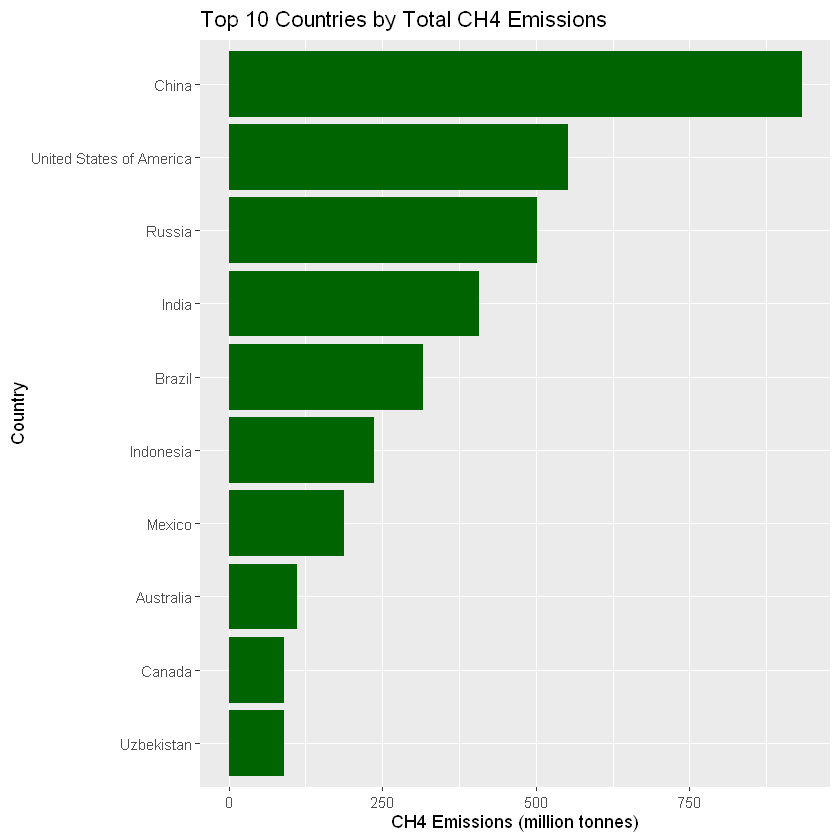

In [130]:
top_ch4 <- df %>% 
  arrange(desc(CH4.emissions)) %>% 
  head(10)

ggplot(top_ch4, aes(x = reorder(Country, CH4.emissions), y = CH4.emissions)) +
  geom_bar(stat = "identity", fill = "darkgreen") +
  coord_flip() +
  labs(title = "Top 10 Countries by Total CH4 Emissions",
       x = "Country", y = "CH4 Emissions (million tonnes)")


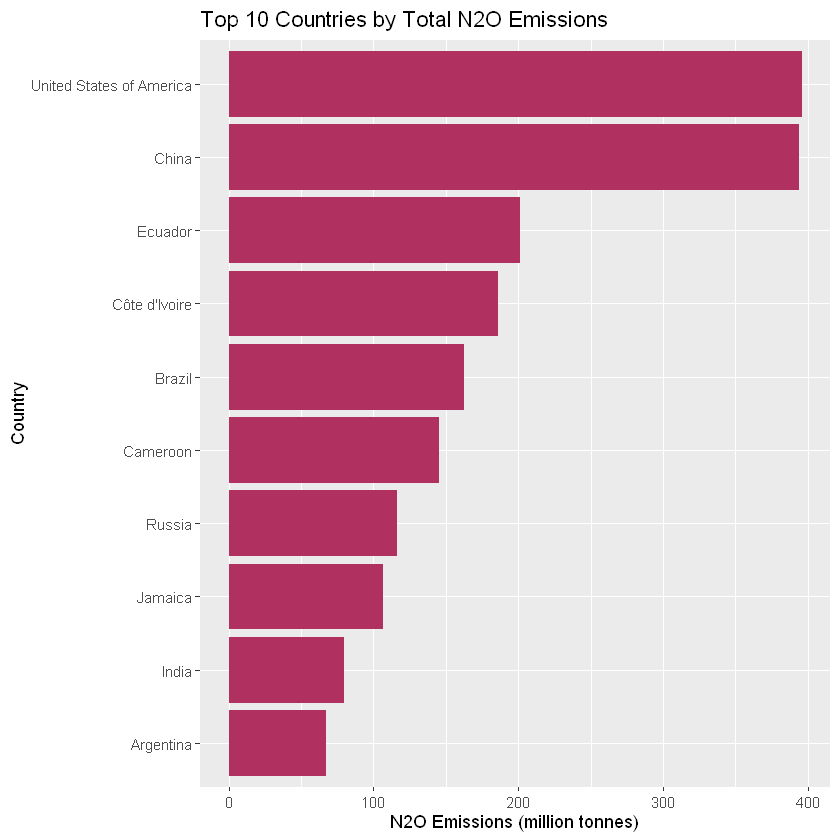

In [131]:
top_ch4 <- df %>% 
  arrange(desc(N2O.emissions)) %>% 
  head(10)

ggplot(top_ch4, aes(x = reorder(Country, N2O.emissions), y = N2O.emissions)) +
  geom_bar(stat = "identity", fill = "maroon") +
  coord_flip() +
  labs(title = "Top 10 Countries by Total N2O Emissions",
       x = "Country", y = "N2O Emissions (million tonnes)")


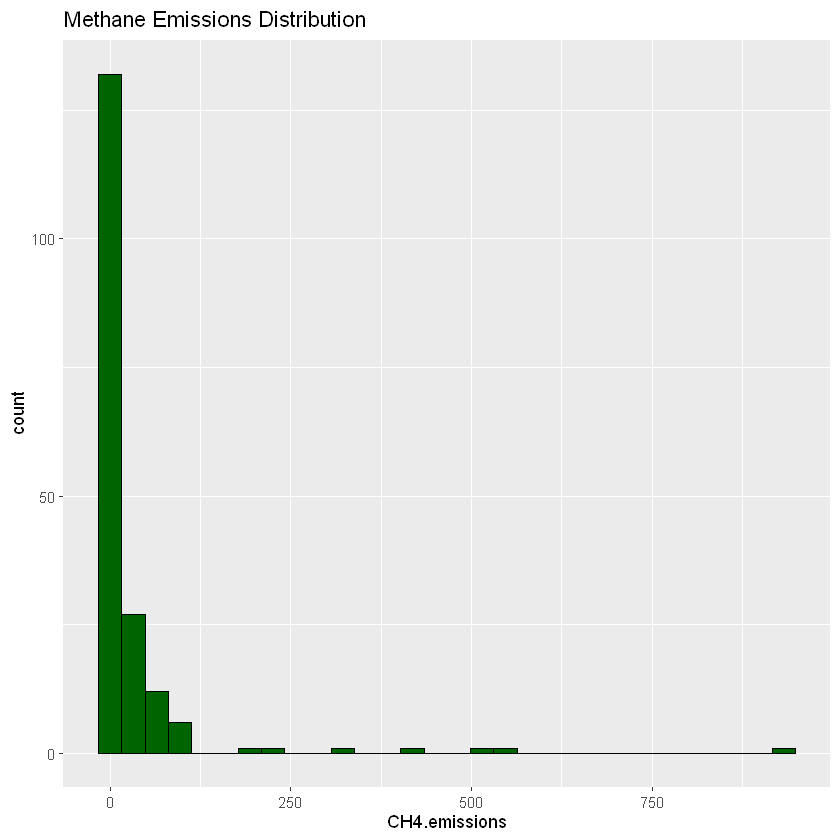

In [132]:
ggplot(df, aes(x = CH4.emissions)) +
  geom_histogram(bins = 30, fill = "darkgreen", color = "black") +
  ggtitle("Methane Emissions Distribution")

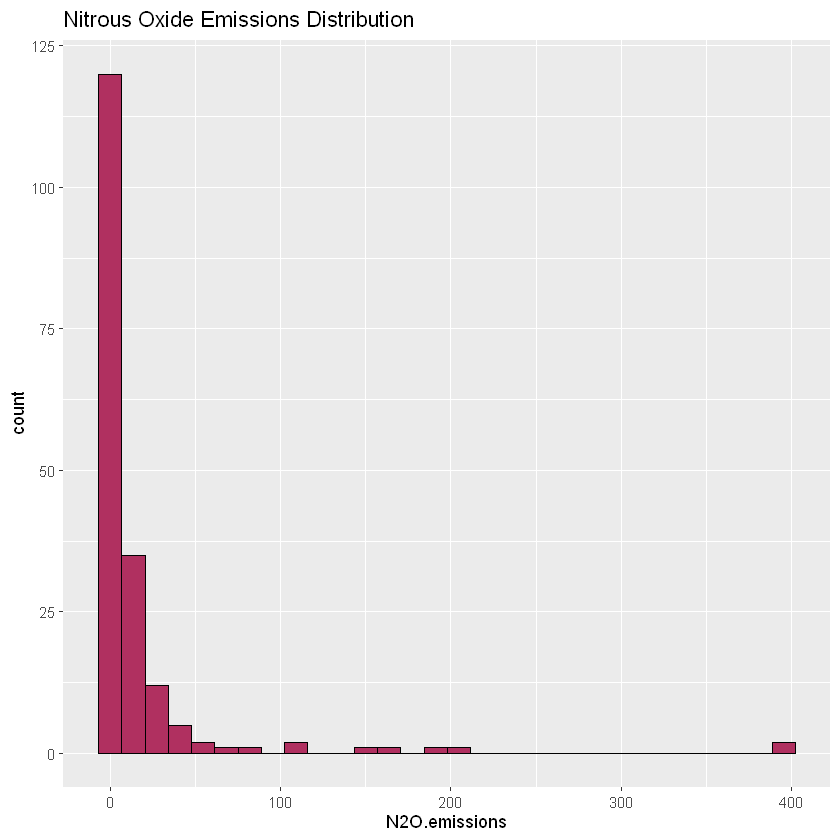

In [133]:
ggplot(df, aes(x = N2O.emissions)) +
  geom_histogram(bins = 30, fill = "maroon", color = "black") +
  ggtitle("Nitrous Oxide Emissions Distribution")

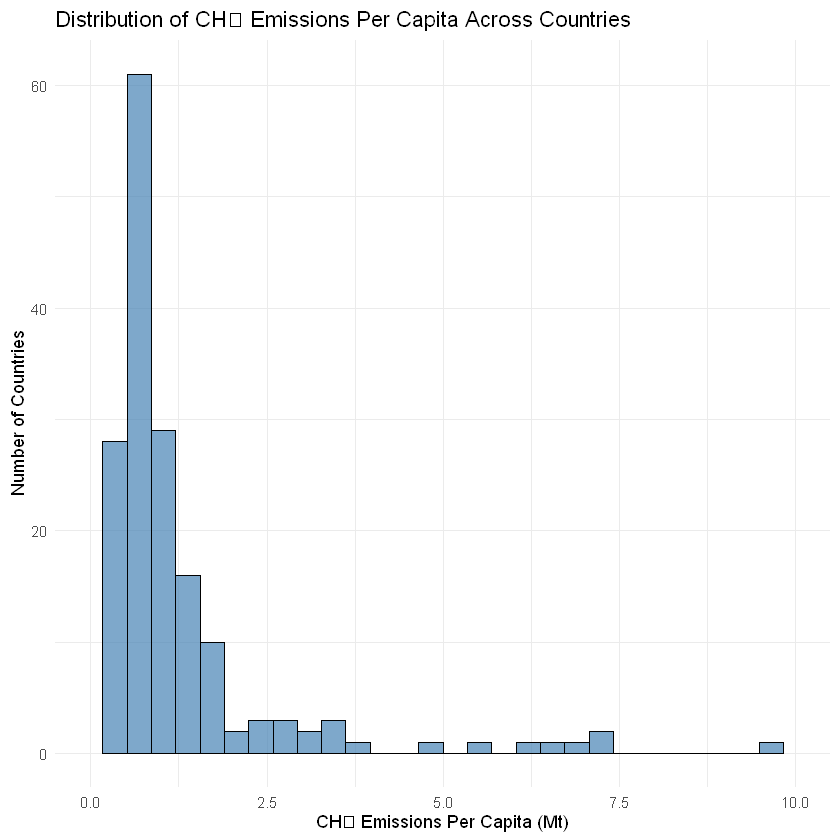

In [135]:
# Histogram of CH4 per capita
my_histogram <- ggplot(df, aes(x = CH4.emissions.per.capita)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "black", alpha = 0.7) +
  labs(
    title = "Distribution of CH₄ Emissions Per Capita Across Countries",
    x = "CH₄ Emissions Per Capita (Mt)",
    y = "Number of Countries"
  ) +
  theme_minimal() +
  xlim(0, 10) # Excluding extreme outliers

# Printing the plot while muting the outlier warnings
suppressWarnings(print(my_histogram))

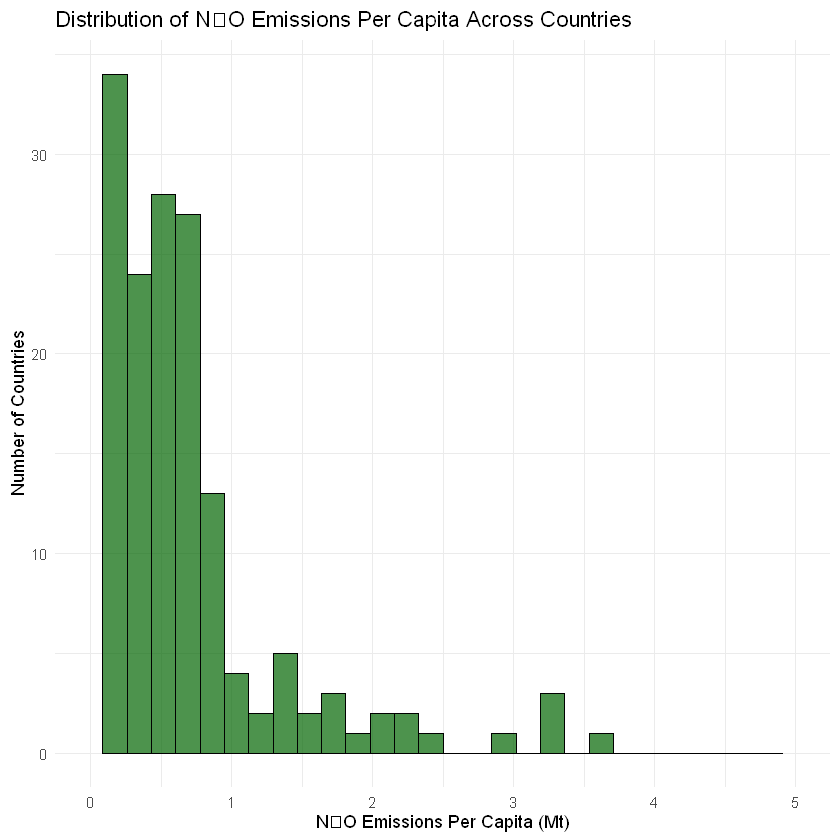

In [137]:
# Histogram of N20 per capita
my_n2o_histogram <- ggplot(df, aes(x = N2O.emissions.per.capita)) +
  geom_histogram(bins = 30, fill = "darkgreen", color = "black", alpha = 0.7) +
  labs(
    title = "Distribution of N₂O Emissions Per Capita Across Countries",
    x = "N₂O Emissions Per Capita (Mt)",
    y = "Number of Countries"
  ) +
  theme_minimal() +
  xlim(0, 5)

suppressWarnings(print(my_n2o_histogram))

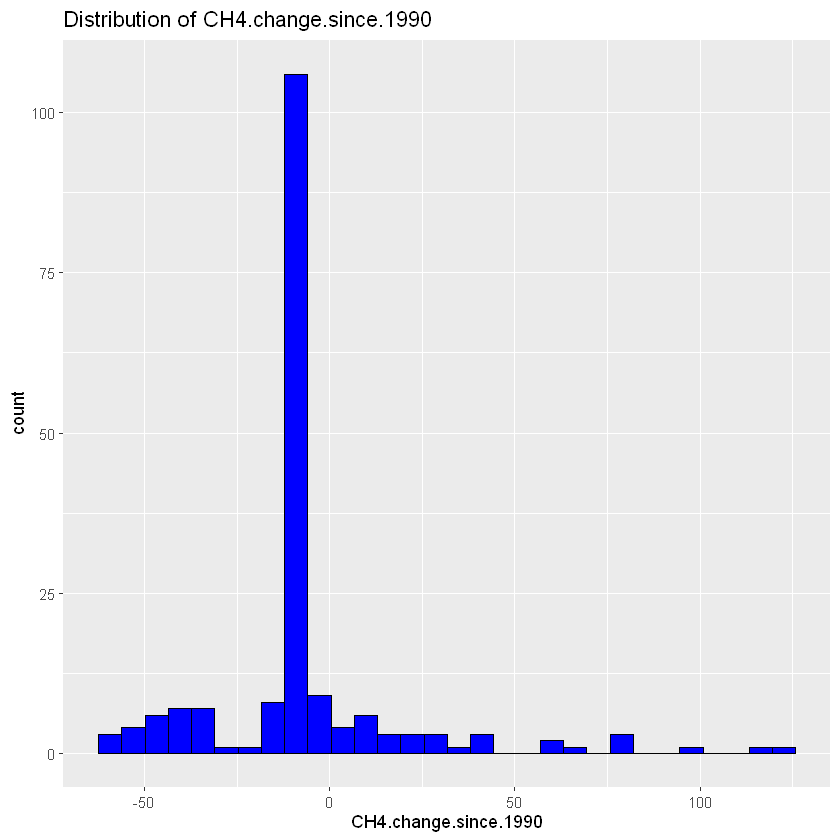

In [90]:
ggplot(df, aes(x = CH4.change.since.1990)) +
  geom_histogram(bins = 30, fill = "blue", color = "black", na.rm=TRUE) +
  ggtitle("Distribution of CH4.change.since.1990")

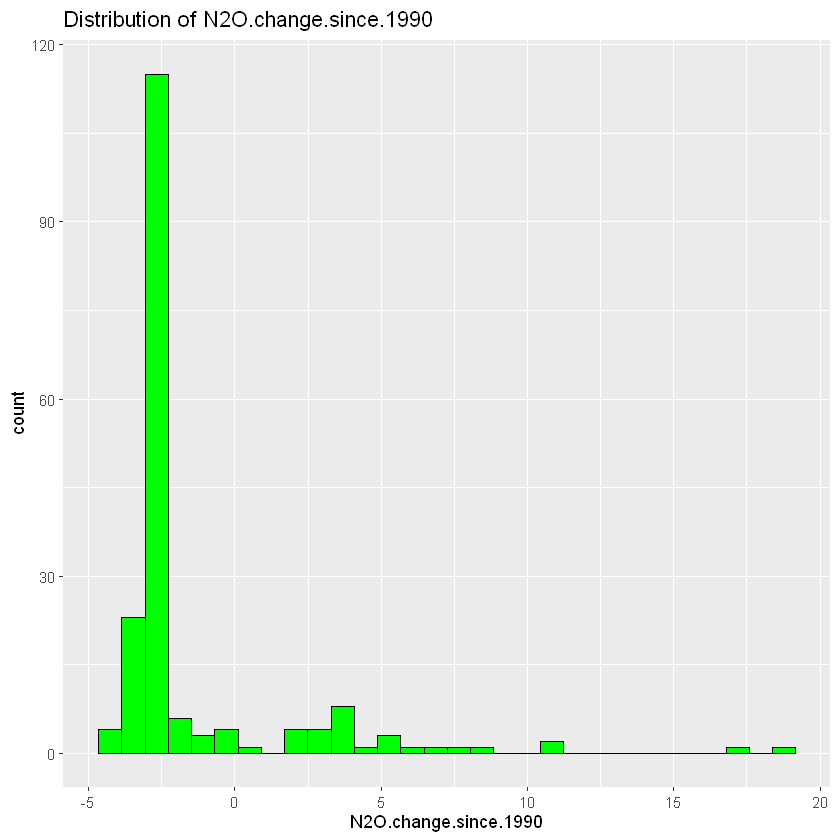

In [91]:
ggplot(df, aes(x = N2O.change.since.1990)) +
  geom_histogram(bins = 30, fill = "green", color = "black", na.rm=TRUE) +
  ggtitle("Distribution of N2O.change.since.1990")

## Feature engineering

In [93]:
#Feature Engineering , new variable
df$Total_Emissions <- df$CH4.emissions + df$N2O.emissions

In [94]:
head(df)

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,CH4.change.since.1990,N2O.emissions,N2O.emissions.per.capita,N2O.change.since.1990,Total_Emissions
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Afghanistan,2005,10.16,0.42,-7.035,5.94,0.24,-2.294505,16.10
Albania,1994,2.14,0.68,-7.035,0.29,0.09,-2.294505,2.43
Algeria,2000,32.92,1.06,-7.035,6.50,0.21,-2.294505,39.42
Angola,2005,19.93,1.11,-7.035,13.87,0.77,-2.294505,33.80
Antigua and Barbuda,2000,0.14,1.83,43.740,0.08,1.08,17.321972,0.22
Argentina,2000,84.85,2.29,10.500,67.50,1.82,3.116183,152.35


In [95]:
lowest_tot <- min(df$Total_Emissions)
highest_tot <- max(df$Total_Emissions)
print(lowest_tot )

[1] 0


In [96]:
print(highest_tot)

[1] 1326.96


In [97]:
df <- df %>%
  mutate(Methane_Safety = case_when(
    CH4.emissions >= 0.00 & CH4.emissions <=50  ~ "Safe",
    CH4.emissions >= 51 & CH4.emissions <= 950 ~ "Dangerous",
  ))

In [98]:
df <- df %>%
  mutate(Nitrous_Oxide_Safety = case_when(
    N2O.emissions >= 0.00 & N2O.emissions <= 18 ~ "Safe",
    N2O.emissions >=19  & N2O.emissions <= 400 ~ "Dangerous",
  ))

In [99]:
df <- df %>%
  mutate(Overall_Safety = case_when(
    Total_Emissions >= 0.00 & Total_Emissions <= 68 ~ "Safe",
    Total_Emissions >= 69 & Total_Emissions <= 1327.00 ~ "Dangerous",
  ))

In [125]:
head(df)

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,CH4.change.since.1990,N2O.emissions,N2O.emissions.per.capita,N2O.change.since.1990,Total_Emissions,Methane_Safety,Nitrous_Oxide_Safety,Overall_Safety,Emission_Ratio,Pollution_Profile
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>
Afghanistan,2005,10.16,0.42,-7.035,5.94,0.24,-2.294505,16.10,Safe,Safe,Safe,1.710409,Balanced Profile
Albania,1994,2.14,0.68,-7.035,0.29,0.09,-2.294505,2.43,Safe,Safe,Safe,7.376767,Methane-Dominant
Algeria,2000,32.92,1.06,-7.035,6.50,0.21,-2.294505,39.42,Safe,Safe,Safe,5.064537,Methane-Dominant
Angola,2005,19.93,1.11,-7.035,13.87,0.77,-2.294505,33.80,Safe,Safe,Safe,1.436904,Balanced Profile
Antigua and Barb.,2000,0.14,1.83,43.740,0.08,1.08,17.321972,0.22,Safe,Safe,Safe,1.747815,Balanced Profile
Argentina,2000,84.85,2.29,10.500,67.50,1.82,3.116183,152.35,Dangerous,Dangerous,Dangerous,1.257035,Balanced Profile


In [101]:
# Feature Engineering: CH4 to N2O Ratio
df <- df %>%
  mutate(
    Emission_Ratio = CH4.emissions / (N2O.emissions + 0.0001),
    
    # Categorizing the profile based on the ratio
    Pollution_Profile = case_when(
      Emission_Ratio > 2 ~ "Methane-Dominant",
      Emission_Ratio < 0.5 ~ "Nitrous-Dominant",
      TRUE ~ "Balanced Profile"
    )
  )

In [102]:
head(df)

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,CH4.change.since.1990,N2O.emissions,N2O.emissions.per.capita,N2O.change.since.1990,Total_Emissions,Methane_Safety,Nitrous_Oxide_Safety,Overall_Safety,Emission_Ratio,Pollution_Profile
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>
Afghanistan,2005,10.16,0.42,-7.035,5.94,0.24,-2.294505,16.10,Safe,Safe,Safe,1.710409,Balanced Profile
Albania,1994,2.14,0.68,-7.035,0.29,0.09,-2.294505,2.43,Safe,Safe,Safe,7.376767,Methane-Dominant
Algeria,2000,32.92,1.06,-7.035,6.50,0.21,-2.294505,39.42,Safe,Safe,Safe,5.064537,Methane-Dominant
Angola,2005,19.93,1.11,-7.035,13.87,0.77,-2.294505,33.80,Safe,Safe,Safe,1.436904,Balanced Profile
Antigua and Barbuda,2000,0.14,1.83,43.740,0.08,1.08,17.321972,0.22,Safe,Safe,Safe,1.747815,Balanced Profile
Argentina,2000,84.85,2.29,10.500,67.50,1.82,3.116183,152.35,Dangerous,Dangerous,Dangerous,1.257035,Balanced Profile


## More Visualizations

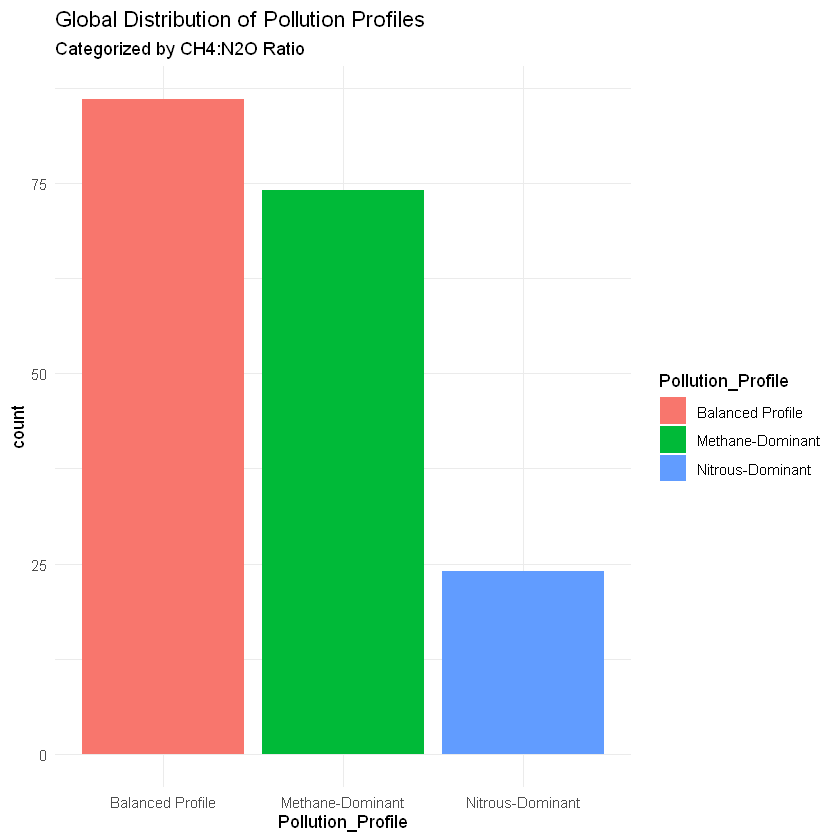

In [104]:
ggplot(df, aes(x = Pollution_Profile, fill = Pollution_Profile)) +
  geom_bar() +
  theme_minimal() +
  labs(title = "Global Distribution of Pollution Profiles",
       subtitle = "Categorized by CH4:N2O Ratio")

In [105]:
library(rnaturalearth)
library(sf)
world <- ne_countries(scale = "medium", returnclass = "sf")

Linking to GEOS 3.14.1, GDAL 3.12.1, PROJ 9.7.1; sf_use_s2() is TRUE



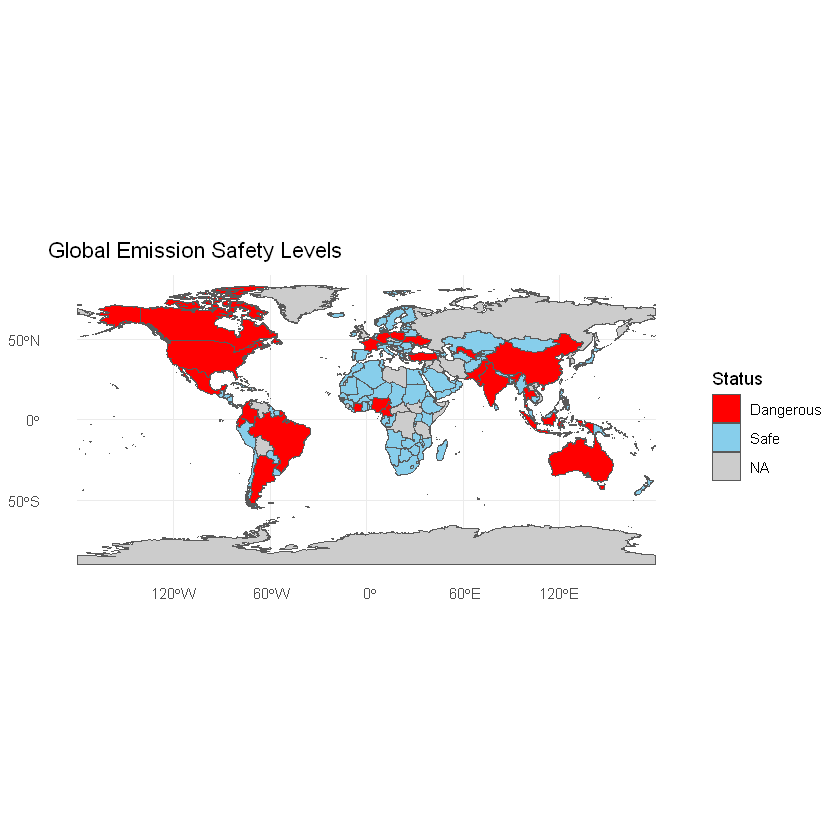

In [106]:
#Choropleth Map
# Joining the data
map_data <- left_join(world, df, by = c("name" = "Country"))

# Check if the column exists
if(!"Overall_Safety" %in% colnames(map_data)) {
  stop("The column 'Overall_Safety' is missing from map_data. Check your join!")
}

ggplot(data = map_data) +
  geom_sf(aes(fill = Overall_Safety)) + 
  scale_fill_manual(values = c("Safe" = "skyblue", "Dangerous" = "red"), 
                    na.value = "grey80") +
  theme_minimal() +
  labs(title = "Global Emission Safety Levels",
       fill = "Status")

In [107]:
# Create a vector of all names in your data that aren't on the map
missing_countries <- setdiff(df$Country, world$name)

# Display the full list
print(missing_countries)

 [1] "Antigua and Barbuda"                                 
 [2] "Bolivia (Plurinational State of)"                    
 [3] "Bosnia and Herzegovina"                              
 [4] "Central African Republic"                            
 [5] "Cook Islands"                                        
 [6] "Czech Republic"                                      
 [7] "Democratic People's Republic of Korea"               
 [8] "Democratic Republic of the Congo"                    
 [9] "Dominican Republic"                                  
[10] "Iran (Islamic Republic of)"                          
[11] "Lao People's Democratic Republic"                    
[12] "Micronesia (Federated States of)"                    
[13] "Republic of Korea"                                   
[14] "Republic of Moldova"                                 
[15] "Russian Federation"                                  
[16] "Saint Kitts and Nevis"                               
[17] "Saint Vincent and the Grenadines" 

In [108]:
#Identifying which names in our data are missing from the map
mismatched_names <- setdiff(df$Country, world$name)

# Using 'stringdist' logic to find the closest match in the map library
audit_table <- data.frame(
  Dataset_Name = mismatched_names,
  Suggested_Map_Name = sapply(mismatched_names, function(x) {
    # This finds the name in 'world' with the smallest spelling difference
    world$name[agrep(x, world$name, max.distance = 0.3, ignore.case = TRUE)][1]
  })
)

print(audit_table)

                                                                                             Dataset_Name
Antigua and Barbuda                                                                   Antigua and Barbuda
Bolivia (Plurinational State of)                                         Bolivia (Plurinational State of)
Bosnia and Herzegovina                                                             Bosnia and Herzegovina
Central African Republic                                                         Central African Republic
Cook Islands                                                                                 Cook Islands
Czech Republic                                                                             Czech Republic
Democratic People's Republic of Korea                               Democratic People's Republic of Korea
Democratic Republic of the Congo                                         Democratic Republic of the Congo
Dominican Republic                            

In [109]:
#Cleaning whitespaces
df$Country <- trimws(df$Country)

#Matching names to the rnaturalearth "world" library
df <- df %>%
  mutate(Country = recode(Country, 
    "Antigua and Barbuda" = "Antigua and Barb.",
    "Bolivia (Plurinational State of)" = "Bolivia",
    "Bosnia and Herzegovina" = "Bosnia and Herz.",
    "Central African Republic" = "Central African Rep.",
    "Cook Islands" = "Cook Is.",
    "Czech Republic" = "Czechia",
    "Democratic People's Republic of Korea" = "North Korea",
    "Democratic Republic of the Congo" = "Dem. Rep. Congo",
    "Dominican Republic" = "Dominican Rep.",
    "Iran (Islamic Republic of)" = "Iran",
    "Lao People's Democratic Republic" = "Laos",
    "Micronesia (Federated States of)" = "Micronesia",
    "Republic of Korea" = "South Korea",
    "Republic of Moldova" = "Moldova",
    "Russian Federation" = "Russia",
    "Saint Kitts and Nevis" = "St. Kitts and Nevis",
    "Saint Vincent and the Grenadines" = "St. Vin. and Gren.",
    "Sao Tome and Principe" = "São Tomé and Principe",
    "Swaziland" = "eSwatini",
    "The former Yugoslav Republic of Macedonia" = "North Macedonia",
    "United Kingdom of Great Britain and Northern Ireland" = "United Kingdom",
    "United Republic of Tanzania" = "Tanzania",
    "Venezuela (Bolivarian Republic of)" = "Venezuela",
    "Viet Nam" = "Vietnam"
  ))

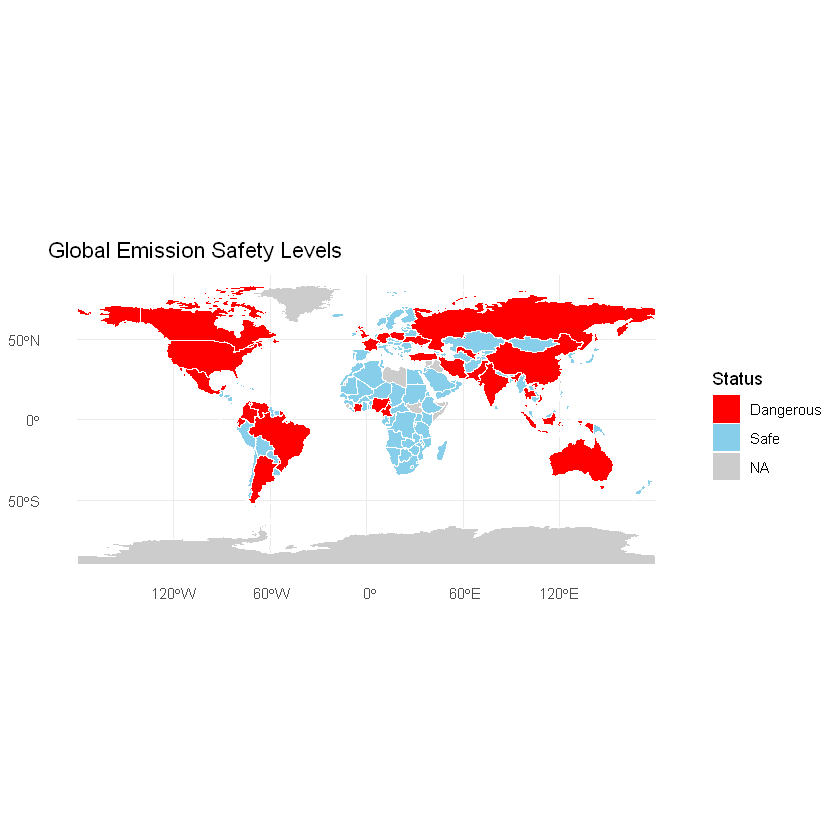

In [110]:
# Joining world data to our df
map_data <- left_join(world, df, by = c("name" = "Country"))


ggplot(data = map_data) +
  geom_sf(aes(fill = Overall_Safety), color = "white", size = 0.1) + 
  scale_fill_manual(
    values = c("Safe" = "skyblue", "Dangerous" = "red"), 
    na.value = "grey80"
  ) + 
  theme_minimal() +
  labs(title = "Global Emission Safety Levels", fill = "Status")

## Correlation and Regression Analysis

[1] "Correlation Coefficient (r): 0.799"


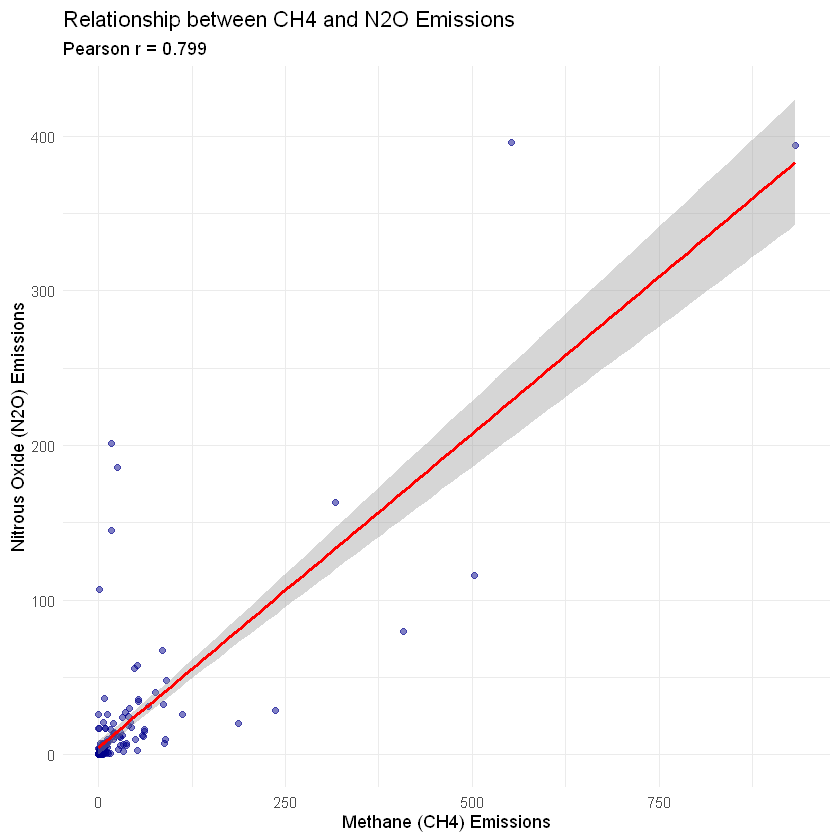

In [147]:
#Correlation Coefficient
correlation_r <- cor(df$CH4.emissions, df$N2O.emissions, use = "complete.obs")
print(paste("Correlation Coefficient (r):", round(correlation_r, 3)))

#Create the Scatterplot
ggplot(df, aes(x = CH4.emissions, y = N2O.emissions)) +
  geom_point(alpha = 0.5, color = "darkblue") +  # Alpha helps see density
  geom_smooth(method = "lm", formula = y ~ x, color = "red", se = TRUE) + # Add trend line
  theme_minimal() +
  labs(
    title = "Relationship between CH4 and N2O Emissions",
    subtitle = paste("Pearson r =", round(correlation_r, 3)),
    x = "Methane (CH4) Emissions",
    y = "Nitrous Oxide (N2O) Emissions"
  )

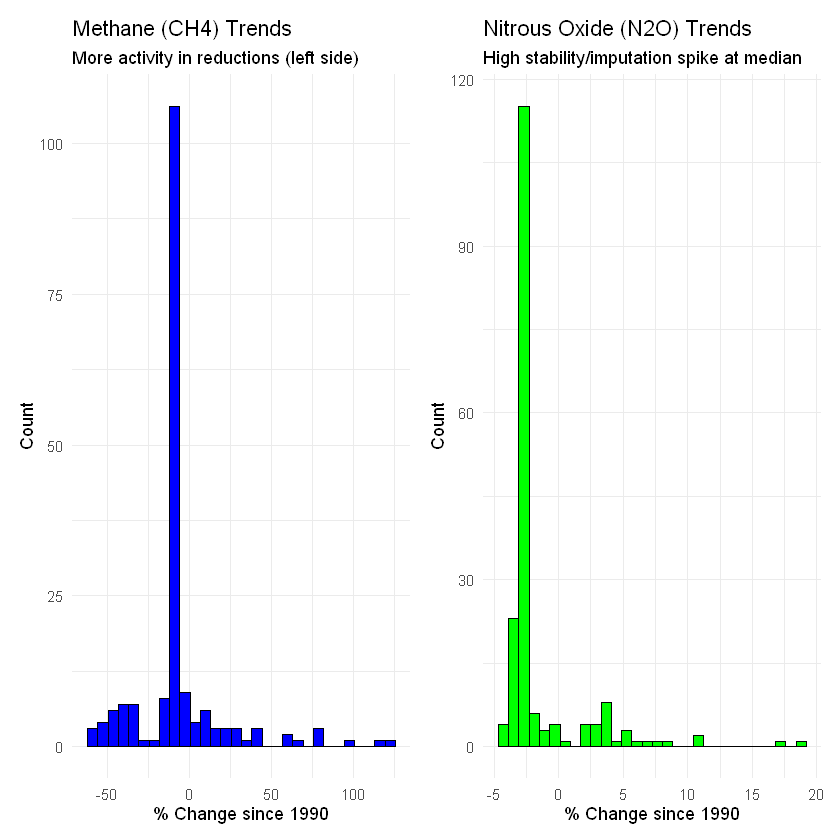

In [123]:
library(patchwork)


p1 <- ggplot(df, aes(x = CH4.change.since.1990)) +
  geom_histogram(bins = 30, fill = "blue", color = "black", na.rm = TRUE) +
  theme_minimal() +
  labs(title = "Methane (CH4) Trends",
       subtitle = "More activity in reductions (left side)",
       x = "% Change since 1990", y = "Count")


p2 <- ggplot(df, aes(x = N2O.change.since.1990)) +
  geom_histogram(bins = 30, fill = "green", color = "black", na.rm = TRUE) +
  theme_minimal() +
  labs(title = "Nitrous Oxide (N2O) Trends",
       subtitle = "High stability/imputation spike at median",
       x = "% Change since 1990", y = "Count")

combined_plot <- p1 + p2

combined_plot


ggsave("Emissions_Comparison_Milestone3.png", plot = combined_plot, width = 12, height = 6)

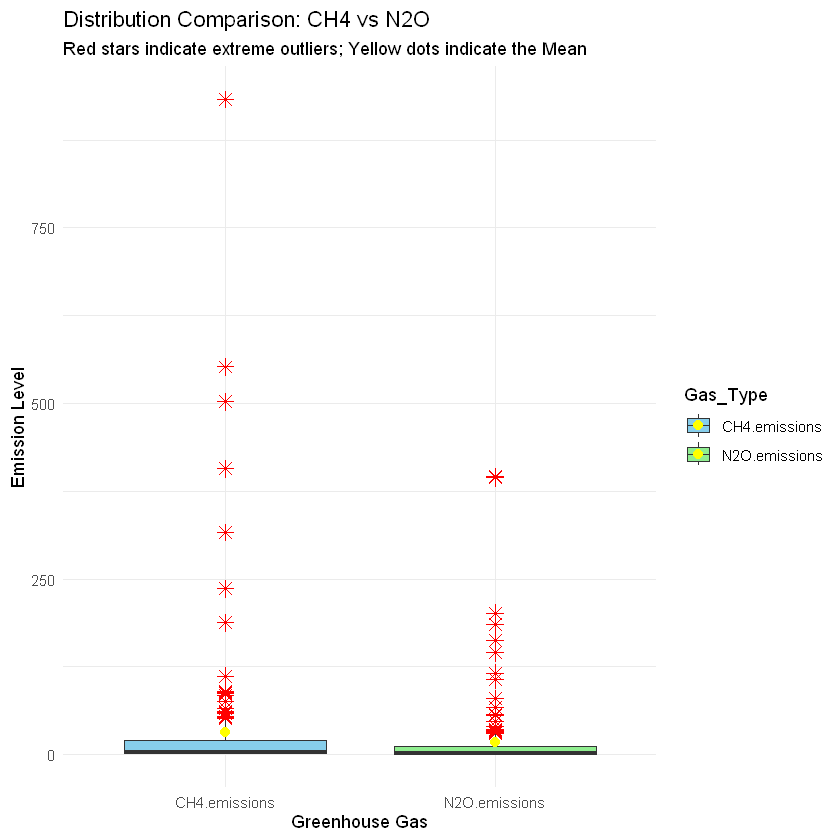

In [113]:
#Reshape data 
df_long <- df %>%
  pivot_longer(cols = c(CH4.emissions, N2O.emissions), 
               names_to = "Gas_Type", 
               values_to = "Emissions")


ggplot(df_long, aes(x = Gas_Type, y = Emissions, fill = Gas_Type)) +
  geom_boxplot(outlier.colour = "red", outlier.shape = 8, outlier.size = 3) +
  stat_summary(fun = mean, geom = "point", shape = 20, size = 4, color = "yellow") +
  scale_fill_manual(values = c("skyblue", "lightgreen")) +
  theme_minimal() +
  labs(
    title = "Distribution Comparison: CH4 vs N2O",
    subtitle = "Red stars indicate extreme outliers; Yellow dots indicate the Mean",
    x = "Greenhouse Gas",
    y = "Emission Level"
  )

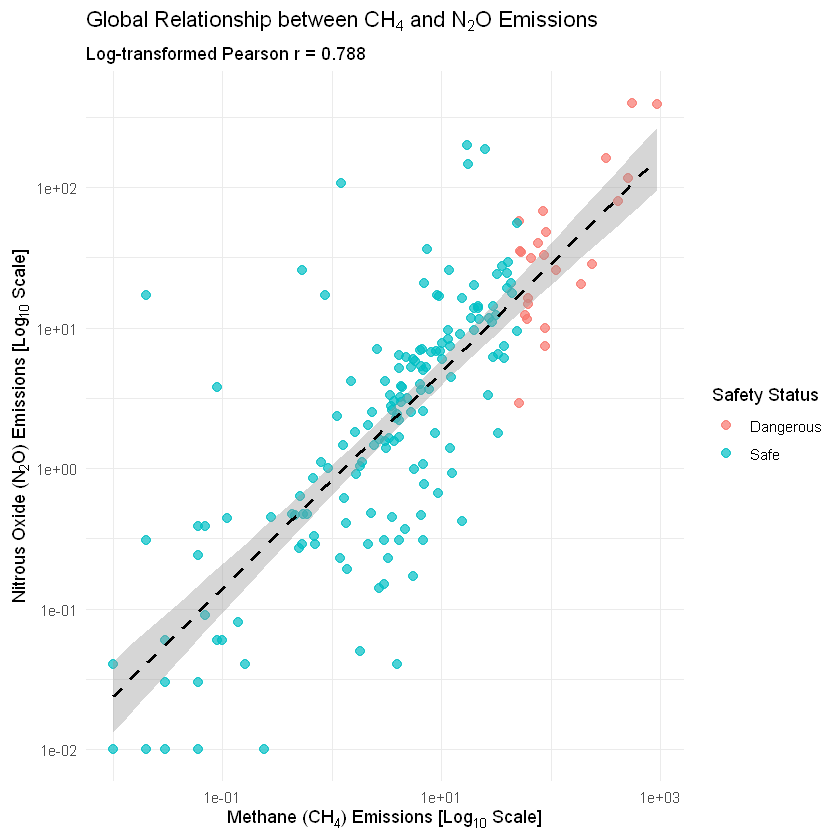

In [145]:
# Correlation calculation
correlation_r <- cor(log10(df_clean$CH4.emissions), 
                     log10(df_clean$N2O.emissions), 
                     use = "complete.obs")

#Scatterplot for Methane and Nitrous Oxide
ggplot(df_clean, aes(x = CH4.emissions, y = N2O.emissions)) +
  geom_point(aes(color = Methane_Safety), alpha = 0.7, size = 2.5) +  
  geom_smooth(method = "lm", formula = y ~ x, color = "black", se = TRUE, linetype = "dashed") + 
  scale_x_log10() + 
  scale_y_log10() + 
  theme_minimal() +
  labs(
    title = expression("Global Relationship between CH"[4]*" and N"[2]*"O Emissions"),
    subtitle = paste("Log-transformed Pearson r =", round(correlation_r, 3)),
    x = expression("Methane (CH"[4]*") Emissions [Log"[10]*" Scale]"),
    y = expression("Nitrous Oxide (N"[2]*"O) Emissions [Log"[10]*" Scale]"),
    color = "Safety Status"
  )

In [141]:
# Correlation between CH₄ and N₂O per capita
cor(df$CH4.emissions.per.capita, df$N2O.emissions.per.capita, use = "complete.obs")

# Correlation matrix of all numeric variables
numeric_vars <- df[, c("CH4.emissions.per.capita", "N2O.emissions.per.capita", 
                       "CH4.change.since.1990", "N2O.change.since.1990", 
                       "Total_Emissions")]
cor(numeric_vars, use = "complete.obs")

[1] -0.0074534

,CH4.emissions.per.capita,N2O.emissions.per.capita,CH4.change.since.1990,N2O.change.since.1990,Total_Emissions
CH4.emissions.per.capita,1.000000000,-0.0074534,-0.005011185,-0.04309563,-0.01490175
N2O.emissions.per.capita,-0.007453400,1.0000000,0.209591092,0.10858054,0.11357068
CH4.change.since.1990,-0.005011185,0.2095911,1.000000000,0.48262580,0.09391179
N2O.change.since.1990,-0.043095626,0.1085805,0.482625802,1.00000000,0.03812508
Total_Emissions,-0.014901745,0.1135707,0.093911789,0.03812508,1.00000000


In [115]:
# Linear Regression Model
model <- lm(N2O.emissions ~ CH4.emissions, data = df)

# Statistical Summary
summary(model)


Call:
lm(formula = N2O.emissions ~ CH4.emissions, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-92.619  -4.894  -4.148  -1.075 190.004 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)    4.50413    2.30255   1.956    0.052 .  
CH4.emissions  0.40605    0.02263  17.946   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 29.76 on 182 degrees of freedom
Multiple R-squared:  0.6389,	Adjusted R-squared:  0.637 
F-statistic: 322.1 on 1 and 182 DF,  p-value: < 2.2e-16


In [116]:
# Independent T-test
#Do "Dangerous" methane emitters also have significantly higher N2O emissions on average compared to "Safe" ones?
t_test_result <- t.test(N2O.emissions ~ Methane_Safety, data = df)
print(t_test_result)


	Welch Two Sample t-test

data:  N2O.emissions by Methane_Safety
t = 2.7372, df = 22.363, p-value = 0.01192
alternative hypothesis: true difference in means between group Dangerous and group Safe is not equal to 0
95 percent confidence interval:
  15.13289 109.39649
sample estimates:
mean in group Dangerous      mean in group Safe 
              71.523913                9.259221 



In [117]:
# Creating a contingency table
table_data <- table(df$Methane_Safety, df$Pollution_Profile)

# Run Chi-Square
chi_sq <- chisq.test(table_data)
print(chi_sq)

Warning message in chisq.test(table_data):
"Chi-squared approximation may be incorrect"



	Pearson's Chi-squared test

data:  table_data
X-squared = 8.3175, df = 2, p-value = 0.01563



In [118]:
# If your table is small (e.g., 2x2), use this:
fisher.test(table_data)

# If your table is larger (e.g., 3x3) and the test takes too long:
chisq.test(table_data, simulate.p.value = TRUE, B = 2000)


	Fisher's Exact Test for Count Data

data:  table_data
p-value = 0.01325
alternative hypothesis: two.sided



	Pearson's Chi-squared test with simulated p-value (based on 2000
	replicates)

data:  table_data
X-squared = 8.3175, df = NA, p-value = 0.01149


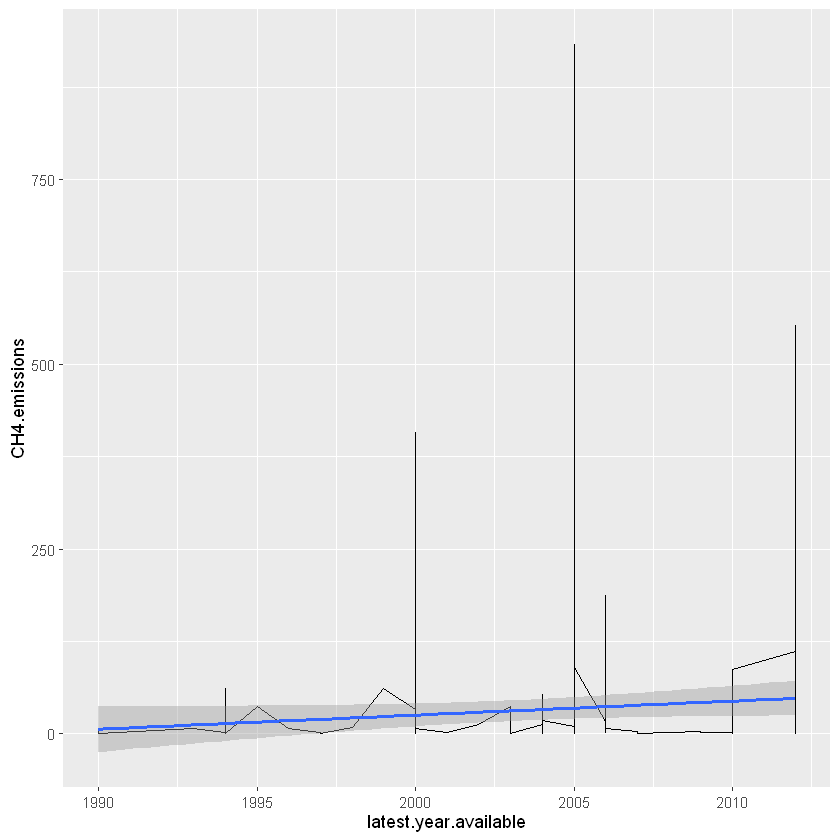

In [119]:
# Simple Trend Model
trend_model <- lm(CH4.emissions ~ latest.year.available,data = df)
# Plotting the trend
ggplot(df, aes(x=latest.year.available, y=CH4.emissions)) + geom_line() + geom_smooth(method="lm", formula = y ~ x)

Warning message in scale_y_log10():
"log-10 transformation introduced infinite values."
Warning message in scale_y_log10():
"log-10 transformation introduced infinite values."
`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 3 rows containing non-finite outside the scale range (`stat_smooth()`)."


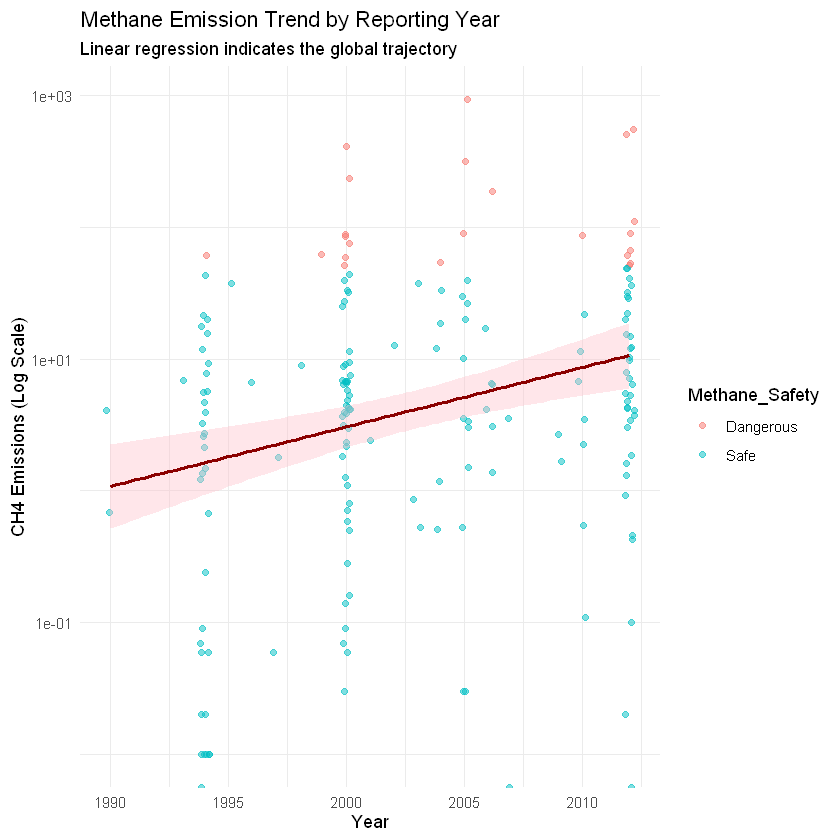

In [120]:
ggplot(df, aes(x = latest.year.available, y = CH4.emissions)) +
  geom_jitter(width = 0.2, alpha = 0.5, aes(color = Methane_Safety)) + 
  geom_smooth(method = "lm", color = "darkred", fill = "pink") + 
  scale_y_log10() + 
  theme_minimal() +
  labs(title = "Methane Emission Trend by Reporting Year",
       subtitle = "Linear regression indicates the global trajectory",
       x = "Year", y = "CH4 Emissions (Log Scale)")

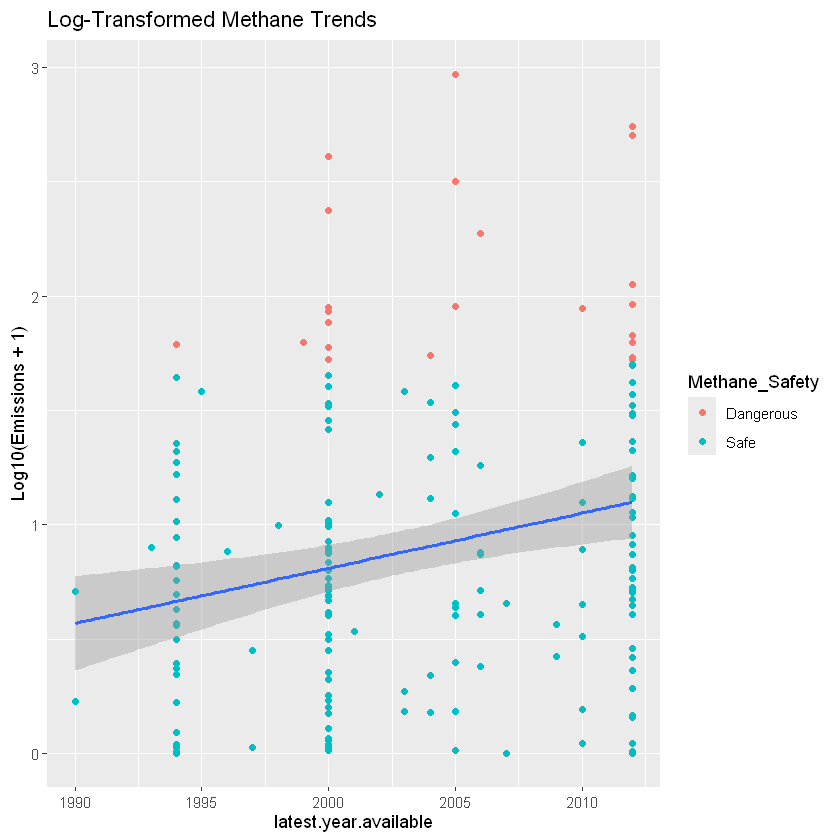

In [121]:
# Instead of scale_y_log10(), transform the aesthetic directly
ggplot(df, aes(x = latest.year.available, y = log10(CH4.emissions + 1))) + 
  geom_point(aes(color = Methane_Safety)) +
  geom_smooth(method = "lm", formula = y ~ x) +
  labs(title = "Log-Transformed Methane Trends",
       y = "Log10(Emissions + 1)")

In [122]:
# Log-Log Regression for highly skewed data
log_model <- lm(log(N2O.emissions + 1) ~ log(CH4.emissions + 1), data = df)
summary(log_model)


Call:
lm(formula = log(N2O.emissions + 1) ~ log(CH4.emissions + 1), 
    data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.8611 -0.3395 -0.0636  0.2456  3.9276 

Coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)             0.16989    0.10407   1.632    0.104    
log(CH4.emissions + 1)  0.72775    0.04105  17.730   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.8474 on 182 degrees of freedom
Multiple R-squared:  0.6333,	Adjusted R-squared:  0.6313 
F-statistic: 314.4 on 1 and 182 DF,  p-value: < 2.2e-16


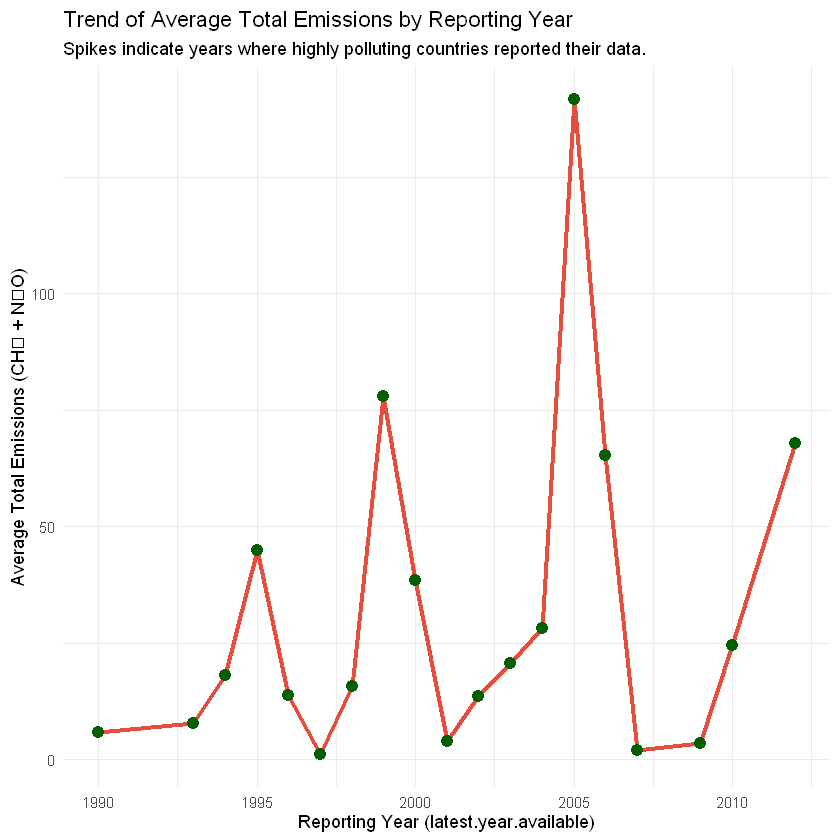

In [149]:
# TREND -> Line Chart
# Tracking how average total emissions look based on the reporting year
df %>%
  group_by(latest.year.available) %>%
  summarize(Avg_Total = mean(Total_Emissions, na.rm = TRUE)) %>%
  drop_na() %>%
  ggplot(aes(x = latest.year.available, y = Avg_Total)) +
  geom_line(color = "#E74C3C", linewidth = 1.2) +
  geom_point(color = "#045e02", size = 3) +
  theme_minimal() +
  labs(title = "Trend of Average Total Emissions by Reporting Year",
       subtitle = "Spikes indicate years where highly polluting countries reported their data.",
       x = "Reporting Year (latest.year.available)",
       y = "Average Total Emissions (CH₄ + N₂O)")

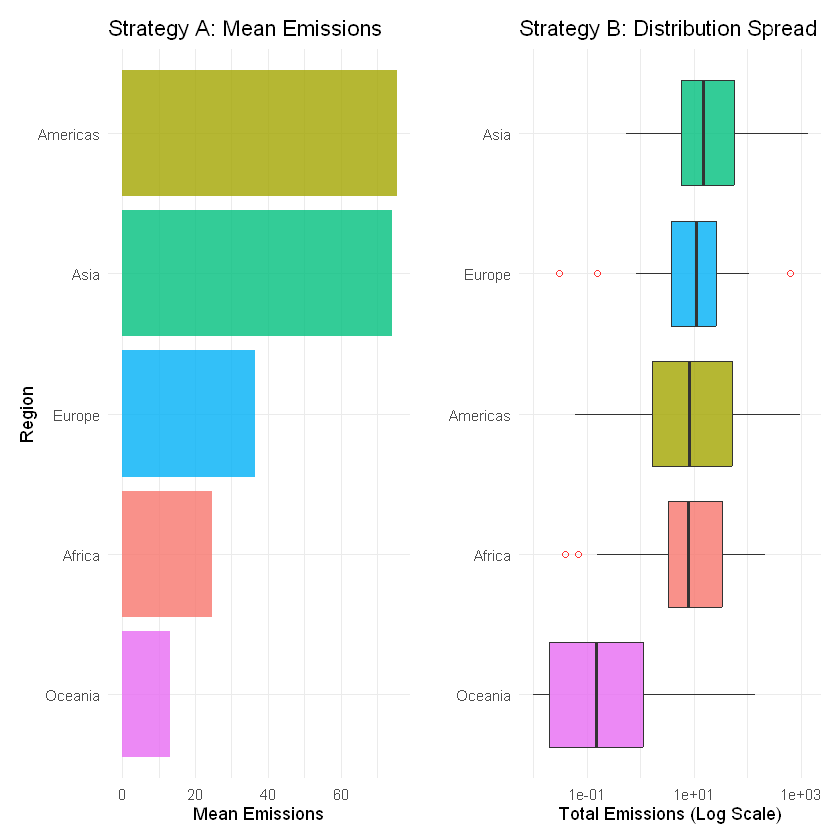

In [157]:
#Feature Engineering with Custom Matches
library(countrycode)
df <- df %>%
  mutate(Region = countrycode(Country, 
                              origin = "country.name", 
                              destination = "continent",
                              custom_match = c('Micronesia' = 'Oceania', 
                                               'St. Vin. and Gren.' = 'Americas')))

#Strategy A (Mean) -Bar graph
p1 <- df %>%
  group_by(Region) %>%
  summarize(Avg_Total = mean(Total_Emissions)) %>%
  drop_na(Region) %>%
  ggplot(aes(x = reorder(Region, Avg_Total), y = Avg_Total, fill = Region)) +
  geom_col(alpha = 0.8) +
  coord_flip() +
  theme_minimal() +
  theme(legend.position = "none") +
  labs(title = "Strategy A: Mean Emissions", x = "Region", y = "Mean Emissions")

# 3. Strategy B (Distribution) - Box plot
p2 <- df %>% 
  drop_na(Region) %>%
  # We filter for > 0 to avoid the "Infinite" warning in log scale
  filter(Total_Emissions > 0) %>% 
  ggplot(aes(x = reorder(Region, Total_Emissions, FUN=median), y = Total_Emissions, fill = Region)) +
  geom_boxplot(alpha = 0.8, outlier.colour = "red", outlier.shape = 1) +
  scale_y_log10() + 
  coord_flip() +
  theme_minimal() +
  theme(legend.position = "none") +
  labs(title = "Strategy B: Distribution Spread", x = "", y = "Total Emissions (Log Scale)")

library(patchwork)
p1 + p2

***CHANGES MADE FROM MILESTONE ONE***
* **Milestone Appendix: Documented Changes**
* *Change 1: Skewness Calculation*

* What changed: We changed our skewness calculation from using the population mean to the sample mean.

* What failed: The standard calculation for skewness treats the dataset as a full population. Using this method did not give us an unbiased sample estimation.

* Why it failed: Our data is essentially a sample of environmental tracking, so using the standard population-level formula is statistically inappropriate and yields slightly inaccurate descriptive statistics for a sample.

* Alternative solution: We installed and imported the e1071 library and applied the skewness() function using the type = 2 parameter, which correctly calculates the sample moment.

* *Change 2: Data Transformation Strategy*

* What changed: We moved from using a log transformation to a cubic root transformation.

* What failed: Attempting to apply a standard logarithmic transformation (like log10()) threw mathematical errors and generated NaN (Not a Number) values, which ruined the dataset structure.

* Why it failed: The specific columns we are analyzing (CH4.change.since.1990 and N2O.change.since.1990) represent percentage changes. Many countries have successfully reduced their emissions, resulting in negative values. It is mathematically impossible to calculate the logarithm of a negative number.

* Alternative solution: We implemented a signed cubic root transformation using the formula sign(x) * (abs(x)^(1/3)). This alternative safely handles both positive and negative numbers while still effectively compressing the extreme outliers to fix the data's right-skewness.